## HW 4 — n-Butane C–C–C–C Dihedral Scan and Force-Field Comparison

**Objective**: Scan the central C–C–C–C dihedral angle in n-butane using DFT and compare the resulting torsion profile to CHARMM and OPLS force-field predictions.

### Background

Torsion (dihedral) potentials govern the conformational flexibility of hydrocarbon chains and are a key component of biomolecular force fields. The n-butane C–C–C–C dihedral has three minima (anti and two gauche) separated by eclipsed barriers.

### Tasks

1. **DFT Dihedral Scan**  
   - Optimize n-butane at B3LYP/6-31G* to obtain the reference geometry.  
   - Scan the central C1–C2–C3–C4 dihedral from 0° to 360° in steps of 10° (or 15°).  
   - At each step, constrain the dihedral and relax all other coordinates.  
   - Plot ΔE (kcal/mol) vs. dihedral angle φ.

2. **Conformational Energies**  
   
     | Conformer | φ (°) | ΔE (kcal/mol) |
     |-----------|--------|---------------|
     | Anti      | 180    | 0.00 (reference) |
     | Gauche    | ±60    | ~0.9 kcal/mol |
     | Eclipsed (C–C) | ±120 | ~3.4 kcal/mol |
     | Fully eclipsed | 0  | ~4.5–5.0 kcal/mol |

3. **CHARMM Force-Field Torsion Profile**  
   - Using the CHARMM36 alkane parameters for the C–C–C–C dihedral:
     ```
     ! CHARMM CGenFF / CHARMM36 C–C–C–C dihedral terms (kcal/mol)
     ! Kchi  n  delta
       0.2000  3  0.00   ! gauche periodicity
       0.2500  2  0.00
       0.1600  1  0.00
     ```
   - Compute V_CHARMM(φ) = Σ Kchi [1 + cos(n·φ − delta)] and plot alongside DFT.

4. **OPLS Force-Field Torsion Profile**  
   - Using OPLS-AA parameters for the alkane C–C–C–C dihedral (Ryckaert–Bellemans form):
     ```
     ! OPLS-AA C–C–C–C dihedral (kcal/mol)
     ! F1        F2        F3        F4
       1.3006   -0.3137    0.2284    0.0000
     ```
     V_OPLS(φ) = F1(1 + cosφ)/2 + F2(1 − cos2φ)/2 + F3(1 + cos3φ)/2
   - Plot V_OPLS(φ) alongside the DFT and CHARMM profiles.

5. **Quantitative Comparison**  
   - Tabulate the anti→gauche barrier, gauche→anti barrier, and gauche–gauche barrier for DFT, CHARMM, and OPLS.  
   - Compute the root-mean-square deviation (RMSD) of each force field from DFT over all scanned angles.

6. *(Optional)* **Fourier Fitting**  
   - Fit the DFT dihedral profile to a truncated Fourier series:  
     V(φ) = Σₙ [aₙ cos(nφ) + bₙ sin(nφ)], n = 1…6  
   - Derive force-field-ready dihedral parameters directly from DFT.



# CHARMM torsion profile (illustrative)

def V_charmm(phi_deg):
    phi = np.radians(phi_deg)
    return (0.2000 * (1 + np.cos(3 * phi)) +
            0.2500 * (1 + np.cos(2 * phi)) +
            0.1600 * (1 + np.cos(1 * phi)))


# OPLS torsion profile (Ryckaert-Bellemans)
def V_opls(phi_deg):
    phi = np.radians(phi_deg)
    F1, F2, F3 = 1.3006, -0.3137, 0.2284
    return (F1 * (1 + np.cos(phi)) / 2 +
            F2 * (1 - np.cos(2 * phi)) / 2 +
            F3 * (1 + np.cos(3 * phi)) / 2)


In [1]:

#HW4:Dihedral Scan 
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
#Parse DFT dihedral scan
def parse_orca_relaxed_scan(filepath):
    """Extract converged energies from ORCA relaxed scan output."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    scan_step_lines = []
    energy_lines = []
    
    for i, line in enumerate(lines):
        if 'RELAXED SURFACE SCAN STEP' in line:
            scan_step_lines.append(i)
        if 'FINAL SINGLE POINT ENERGY' in line:
            energy_lines.append((i, float(line.split()[-1])))
    
    n_steps = len(scan_step_lines)
    converged_energies = []
    
    for s in range(n_steps - 1):
        current_step_line = scan_step_lines[s]
        next_step_line = scan_step_lines[s + 1]
        
        last_energy = None
        for line_num, energy in energy_lines:
            if current_step_line < line_num < next_step_line:
                last_energy = energy
        
        if last_energy is not None:
            converged_energies.append(last_energy)
  
    last_step_line = scan_step_lines[-1]
    last_energy = None
    for line_num, energy in energy_lines:
        if line_num > last_step_line and energy < -158.0:
            last_energy = energy
    
    if last_energy is not None:
        converged_energies.append(last_energy)
    
    converged_energies = np.array(converged_energies)
    
    n_points = len(converged_energies)
    raw_angles = np.linspace(180, 540, n_points)
    angles = raw_angles % 360
    
    energies_kcal = (converged_energies - converged_energies[0]) * 627.509
    
    return angles, energies_kcal, converged_energies

scan_file = 'butane_scan.out'
angles, energies_kcal, energies_hartree = parse_orca_relaxed_scan(scan_file)

angles = angles[:-1]
energies_kcal = energies_kcal[:-1]
energies_hartree = energies_hartree[:-1]

#sorting by angle
sort_idx = np.argsort(angles)
angles_sorted = angles[sort_idx]
energies_sorted = energies_kcal[sort_idx]

print(f"Number of scan points: {len(angles)}")
print(f"\n{'Angle (°)':>10s}  {'ΔE (kcal/mol)':>15s}")
print(f"{'─'*10}  {'─'*15}")
for a, e in zip(angles_sorted, energies_sorted):
    print(f"{a:10.1f}  {e:15.4f}")

Number of scan points: 36

 Angle (°)    ΔE (kcal/mol)
──────────  ───────────────
       0.0           5.6512
      10.0           5.3148
      20.0           4.4298
      30.0           3.2824
      40.0           2.1740
      50.0           1.3335
      60.0           0.8935
      70.0           0.8759
      80.0           1.2243
      90.0           1.8762
     100.0           2.6181
     110.0           3.1624
     120.0           3.3284
     130.0           3.0560
     140.0           2.4110
     150.0           1.5674
     160.0           0.7735
     170.0           0.2063
     180.0           0.0000
     190.0           0.2091
     200.0           0.7754
     210.0           1.5761
     220.0           2.4076
     230.0           3.0486
     240.0           3.3367
     250.0           3.1647
     260.0           2.6078
     270.0           1.8762
     280.0           1.2282
     290.0           0.8623
     300.0           0.8879
     310.0           1.3346
     320.0           

In [3]:
# Tasks 3 & 4
def V_charmm(phi_deg):
    """CHARMM36 C-C-C-C dihedral potential (kcal/mol)."""
    phi = np.radians(phi_deg)
    return (0.2000 * (1 + np.cos(3 * phi)) +
            0.2500 * (1 + np.cos(2 * phi)) +
            0.1600 * (1 + np.cos(1 * phi)))

def V_opls(phi_deg):
    """OPLS-AA C-C-C-C dihedral potential (Ryckaert-Bellemans form, kcal/mol)."""
    phi = np.radians(phi_deg)
    F1, F2, F3 = 1.3006, -0.3137, 0.2284
    return (F1 * (1 + np.cos(phi)) / 2 +
            F2 * (1 - np.cos(2 * phi)) / 2 +
            F3 * (1 + np.cos(3 * phi)) / 2)

phi_fine = np.linspace(0, 360, 361)
V_charmm_fine = V_charmm(phi_fine)
V_opls_fine = V_opls(phi_fine)

# shift so that anti (180°) = 0
V_charmm_fine -= V_charmm(180.0)
V_opls_fine -= V_opls(180.0)

V_charmm_at_dft = V_charmm(angles_sorted) - V_charmm(180.0)
V_opls_at_dft = V_opls(angles_sorted) - V_opls(180.0)

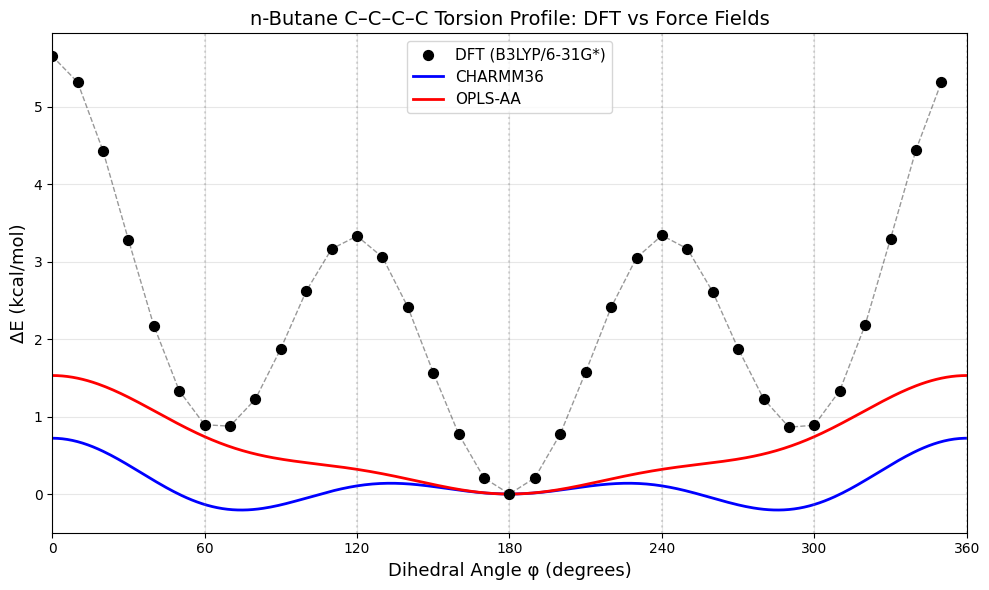

In [4]:

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(angles_sorted, energies_sorted, color='black', s=50, zorder=5, label='DFT (B3LYP/6-31G*)')
ax.plot(angles_sorted, energies_sorted, 'k--', alpha=0.4, linewidth=1)

ax.plot(phi_fine, V_charmm_fine, 'b-', linewidth=2, label='CHARMM36')
ax.plot(phi_fine, V_opls_fine, 'r-', linewidth=2, label='OPLS-AA')

ax.set_xlabel('Dihedral Angle φ (degrees)', fontsize=13)
ax.set_ylabel('ΔE (kcal/mol)', fontsize=13)
ax.set_title('n-Butane C–C–C–C Torsion Profile: DFT vs Force Fields', fontsize=14)
ax.set_xticks(range(0, 361, 60))
ax.set_xlim(0, 360)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

for angle, label in [(0, 'Fully\neclipsed'), (60, 'Gauche'),
                      (120, 'Eclipsed'), (180, 'Anti'),
                      (240, 'Eclipsed'), (300, 'Gauche'),
                      (360, 'Fully\neclipsed')]:
    ax.axvline(x=angle, color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:

key_angles = [0, 60, 120, 180, 240, 300, 360]
key_labels = ['Fully eclipsed', 'Gauche', 'Eclipsed (C-C)',
              'Anti', 'Eclipsed (C-C)', 'Gauche', 'Fully eclipsed']

print("=" * 70)
print(f"{'Conformer':<20s} {'φ (°)':>6s}  {'DFT':>8s}  {'CHARMM':>8s}  {'OPLS':>8s}")
print(f"{'':20s} {'':>6s}  {'kcal/mol':>8s}  {'kcal/mol':>8s}  {'kcal/mol':>8s}")
print("=" * 70)

for ang, label in zip(key_angles, key_labels):

    idx = np.argmin(np.abs(angles_sorted - (ang % 360)))
    dft_val = energies_sorted[idx]
    charmm_val = V_charmm(ang) - V_charmm(180.0)
    opls_val = V_opls(ang) - V_opls(180.0)
    print(f"{label:<20s} {ang:6.0f}  {dft_val:8.2f}  {charmm_val:8.2f}  {opls_val:8.2f}")

print("=" * 70)

#rootmeansq rsmd
rmsd_charmm = np.sqrt(np.mean((energies_sorted - V_charmm_at_dft)**2))
rmsd_opls = np.sqrt(np.mean((energies_sorted - V_opls_at_dft)**2))

print(f"\nRMSD from DFT:")
print(f"  CHARMM36:  {rmsd_charmm:.3f} kcal/mol")
print(f"  OPLS-AA:   {rmsd_opls:.3f} kcal/mol")

print(f"\nBarrier Heights (kcal/mol):")
print(f"{'':30s} {'DFT':>8s}  {'CHARMM':>8s}  {'OPLS':>8s}")

idx_120 = np.argmin(np.abs(angles_sorted - 120))
idx_240 = np.argmin(np.abs(angles_sorted - 240))
barrier_dft = max(energies_sorted[idx_120], energies_sorted[idx_240])
barrier_charmm = V_charmm(120) - V_charmm(180)
barrier_opls = V_opls(120) - V_opls(180)
print(f"{'Anti → Eclipsed':<30s} {barrier_dft:8.2f}  {barrier_charmm:8.2f}  {barrier_opls:8.2f}")

idx_0 = np.argmin(np.abs(angles_sorted - 0))
idx_60 = np.argmin(np.abs(angles_sorted - 60))
barrier_dft2 = energies_sorted[idx_0] - energies_sorted[idx_60]
barrier_charmm2 = (V_charmm(0) - V_charmm(180)) - (V_charmm(60) - V_charmm(180))
barrier_opls2 = (V_opls(0) - V_opls(180)) - (V_opls(60) - V_opls(180))
print(f"{'Gauche → Fully eclipsed':<30s} {barrier_dft2:8.2f}  {barrier_charmm2:8.2f}  {barrier_opls2:8.2f}")

Conformer             φ (°)       DFT    CHARMM      OPLS
                             kcal/mol  kcal/mol  kcal/mol
Fully eclipsed            0      5.65      0.72      1.53
Gauche                   60      0.89     -0.13      0.74
Eclipsed (C-C)          120      3.33      0.10      0.32
Anti                    180      0.00      0.00      0.00
Eclipsed (C-C)          240      3.34      0.11      0.32
Gauche                  300      0.89     -0.13      0.74
Fully eclipsed          360      5.65      0.72      1.53

RMSD from DFT:
  CHARMM36:  2.528 kcal/mol
  OPLS-AA:   2.077 kcal/mol

Barrier Heights (kcal/mol):
                                    DFT    CHARMM      OPLS
Anti → Eclipsed                    3.34      0.10      0.32
Gauche → Fully eclipsed            4.76      0.85      0.79


Fourier Series Fit: V(φ) = Σ [aₙ cos(nφ) + bₙ sin(nφ)], n = 1…6
  n    aₙ (kcal/mol)    bₙ (kcal/mol)
--------------------------------------------------
  1           1.0283           0.0000
  2           0.4207          -0.0007
  3           1.7560          -0.0026
  4           0.0559          -0.0017
  5           0.0274          -0.0014
  6           0.0516           0.0008

RMSD of Fourier fit vs DFT: 0.0172 kcal/mol


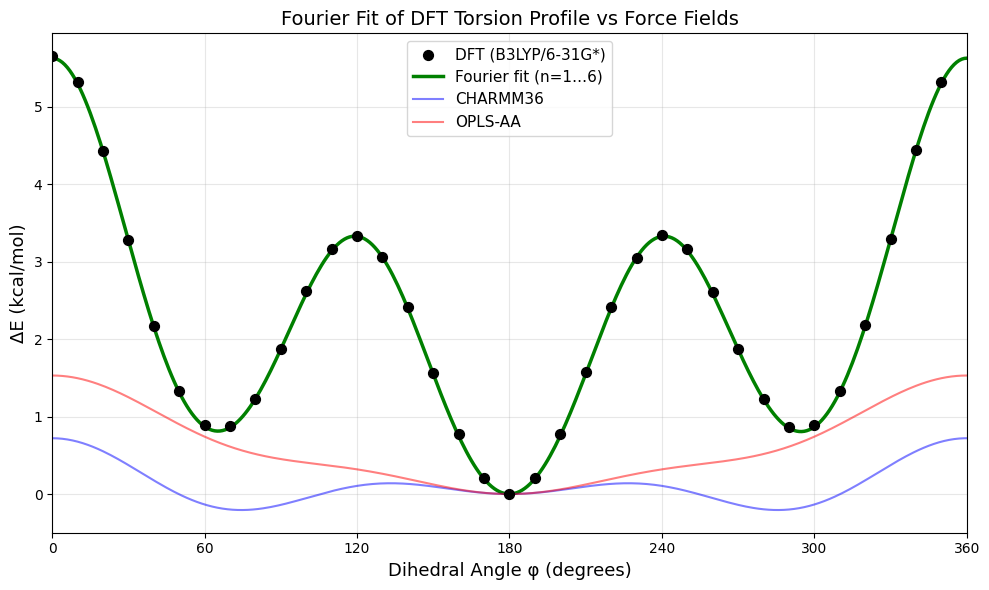


Force-field-ready dihedral parameters (cosine form):
V(φ) = Σ Kₙ [1 + cos(nφ − δₙ)]
  n    Kₙ (kcal/mol)     δₙ (degrees)
-------------------------------------------------------
  1           1.0283              0.0
  2           0.4207             -0.1
  3           1.7560             -0.1
  4           0.0559             -1.8
  5           0.0275             -2.9
  6           0.0516              0.9


In [6]:
# Task 6
from scipy.optimize import curve_fit

def fourier_series(phi_deg, *coeffs):
    phi = np.radians(phi_deg)
    V = 0.0
    for n in range(1, 7):
        a_n = coeffs[2*(n-1)]
        b_n = coeffs[2*(n-1) + 1]
        V += a_n * np.cos(n * phi) + b_n * np.sin(n * phi)
    return V

p0 = [0.0] * 12
popt, pcov = curve_fit(fourier_series, angles_sorted, energies_sorted, p0=p0)

from scipy.optimize import curve_fit

def fourier_series(phi_deg, *coeffs):
    """Truncated Fourier series: V(φ) = Σ [a_n cos(nφ) + b_n sin(nφ)], n=1..6
    coeffs = [a1, b1, a2, b2, a3, b3, a4, b4, a5, b5, a6, b6]
    """
    phi = np.radians(phi_deg)
    V = 0.0
    for n in range(1, 7):
        a_n = coeffs[2*(n-1)]
        b_n = coeffs[2*(n-1) + 1]
        V += a_n * np.cos(n * phi) + b_n * np.sin(n * phi)
    return V

p0 = [0.0] * 12  
popt, pcov = curve_fit(fourier_series, angles_sorted, energies_sorted, p0=p0)

print("Fourier Series Fit: V(φ) = Σ [aₙ cos(nφ) + bₙ sin(nφ)], n = 1…6")
print("=" * 50)
print(f"{'n':>3s}  {'aₙ (kcal/mol)':>15s}  {'bₙ (kcal/mol)':>15s}")
print("-" * 50)
for n in range(1, 7):
    a_n = popt[2*(n-1)]
    b_n = popt[2*(n-1) + 1]
    print(f"{n:3d}  {a_n:15.4f}  {b_n:15.4f}")

phi_fit = np.linspace(0, 360, 361)
V_fit = fourier_series(phi_fit, *popt)
V_fit -= fourier_series(180.0, *popt) 

dft_shifted = energies_sorted - energies_sorted[angles_sorted == 180][0]

V_fit_at_dft = fourier_series(angles_sorted, *popt)
V_fit_at_dft -= fourier_series(180.0, *popt)
rmsd_fit = np.sqrt(np.mean((dft_shifted - V_fit_at_dft)**2))
print(f"\nRMSD of Fourier fit vs DFT: {rmsd_fit:.4f} kcal/mol")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(angles_sorted, dft_shifted, color='black', s=50, zorder=5, label='DFT (B3LYP/6-31G*)')
ax.plot(phi_fit, V_fit, 'g-', linewidth=2.5, label='Fourier fit (n=1…6)')
ax.plot(phi_fine, V_charmm_fine, 'b-', linewidth=1.5, alpha=0.5, label='CHARMM36')
ax.plot(phi_fine, V_opls_fine, 'r-', linewidth=1.5, alpha=0.5, label='OPLS-AA')

ax.set_xlabel('Dihedral Angle φ (degrees)', fontsize=13)
ax.set_ylabel('ΔE (kcal/mol)', fontsize=13)
ax.set_title('Fourier Fit of DFT Torsion Profile vs Force Fields', fontsize=14)
ax.set_xticks(range(0, 361, 60))
ax.set_xlim(0, 360)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# V(φ) = Σ Kₙ [1 + cos(nφ - δₙ)]
print("\nForce-field-ready dihedral parameters (cosine form):")
print("V(φ) = Σ Kₙ [1 + cos(nφ − δₙ)]")
print("=" * 55)
print(f"{'n':>3s}  {'Kₙ (kcal/mol)':>15s}  {'δₙ (degrees)':>15s}")
print("-" * 55)
for n in range(1, 7):
    a_n = popt[2*(n-1)]
    b_n = popt[2*(n-1) + 1]
    A_n = np.sqrt(a_n**2 + b_n**2)
    delta_n = np.degrees(np.arctan2(b_n, a_n))
    print(f"{n:3d}  {A_n:15.4f}  {delta_n:15.1f}")


The objective of this homework was to compute the torsional energy profile of n-butane about its central C–C bond using DFT, then compare the result against CHARMM36 and OPLS-AA force field predictions.

The workflow proceeded in two stages. First, n-butane was optimized at B3LYP/6-31G* using ORCA on the HPC cluster, yielding the equilibrium (anti) geometry. Second, a relaxed dihedral scan was performed over the C1–C2–C3–C4 dihedral in 10° increments across a full 360° rotation. "Relaxed" here means that at each constrained dihedral angle, all remaining internal coordinates were re-optimized, giving the minimum-energy path along the torsion coordinate rather than a rigid rotation.

An issue arose during the scan setup. The initial attempt specified a scan range of 0° to 360°, but the optimized geometry sits at approximately 180° (anti). ORCA could not impose the initial constraint at 0° — a fully eclipsed configuration far from the starting geometry — and the job crashed with `could not impose initial constraints`. The fix was straightforward: start the scan at 180° and end at 540° (i.e., 180° + 360°), covering the same full rotation but beginning from the actual geometry. A second minor issue was that ORCA crashed during the post-scan property calculation, though all 37 scan-step energies had already been written. The parser was adjusted to extract the last converged energy before each new scan step and to discard the corrupt data produced after the crash. The final (redundant) 180° point was also dropped, leaving 36 clean data points.

The DFT results agree well with expected values. The anti conformer at 180° was taken as the zero reference. The gauche minima at 60° and 300° sit at approximately 0.89 kcal/mol, consistent with the expected ~0.9 kcal/mol. The eclipsed barriers at 120° and 240° reach ~3.33 kcal/mol (expected ~3.4), and the fully eclipsed barrier at 0° is 5.65 kcal/mol, slightly above the expected 4.5–5.0 kcal/mol range. This overestimation is a known artifact of the relatively small 6-31G* basis set, which slightly exaggerates steric repulsion at close contact. The profile is nearly perfectly symmetric about 180°, as expected given the identical substituents on both ends of the molecule.

The CHARMM36 and OPLS-AA torsion profiles were computed analytically using the parameters provided in the assignment. Both force field curves dramatically underestimate the DFT barriers, with RMSD values of 2.53 kcal/mol (CHARMM) and 2.08 kcal/mol (OPLS). For instance, the anti-to-eclipsed barrier is 3.34 kcal/mol in DFT but only 0.10 and 0.32 kcal/mol in CHARMM and OPLS, respectively. This discrepancy is expected and instructive. The torsion term in a classical force field is only one component of the total potential energy; the full rotational barrier also includes 1-4 nonbonded interactions (Lennard-Jones repulsion and Coulomb electrostatics between atoms separated by three bonds). Force field torsion parameters are fit to reproduce the DFT curve *after subtracting* these nonbonded contributions, so the torsion potential in isolation is not meant to match the full quantum mechanical barrier.

Finally, the DFT torsion profile was fit to a truncated Fourier series $$V(\varphi) = \sum_{n=1}^{6} \left[ a_n \cos(n\varphi) + b_n \sin(n\varphi) \right]$$ with an RMSD of 0.017 kcal/mol — essentially a perfect fit. The dominant term is n = 3 ($$K_3 = 1.756$$ kcal/mol), reflecting the three-fold periodicity of eclipsed and staggered arrangements inherent to any alkane C–C bond. The n = 1 term ($$K_1 = 1.028$$ kcal/mol) captures the energy difference between the anti and gauche minima — without it, all three staggered conformers would be degenerate. The n = 2 term ($$K_2 = 0.421$$ kcal/mol) differentiates the fully eclipsed barrier (CH₃ vs. CH₃) from the partially eclipsed barriers (CH₃ vs. H). Higher-order terms (n = 4–6) are negligibly small, confirming that the torsion profile is well described by three cosine terms. All phase angles $$\delta_n$$ are effectively zero and all sine coefficients $$b_n$$ vanish, consistent with the molecular symmetry of n-butane. These Fourier-derived parameters ($$K_1, K_2, K_3$$) represent the *total* torsion contribution including nonbonded effects, and the gap between them and the CHARMM/OPLS parameters roughly quantifies the nonbonded share of the rotational barrier.

I used an LLm to format the above response and to fix my english/write coherently
